   car_ID  symboling                   CarName fueltype aspiration doornumber  \
0       1          3        alfa-romero giulia      gas        std        two   
1       2          3       alfa-romero stelvio      gas        std        two   
2       3          1  alfa-romero Quadrifoglio      gas        std        two   
3       4          2               audi 100 ls      gas        std       four   
4       5          2                audi 100ls      gas        std       four   

       carbody drivewheel enginelocation  wheelbase  ...  enginesize  \
0  convertible        rwd          front       88.6  ...         130   
1  convertible        rwd          front       88.6  ...         130   
2    hatchback        rwd          front       94.5  ...         152   
3        sedan        fwd          front       99.8  ...         109   
4        sedan        4wd          front       99.4  ...         136   

   fuelsystem  boreratio  stroke compressionratio horsepower  peakrpm citympg  \

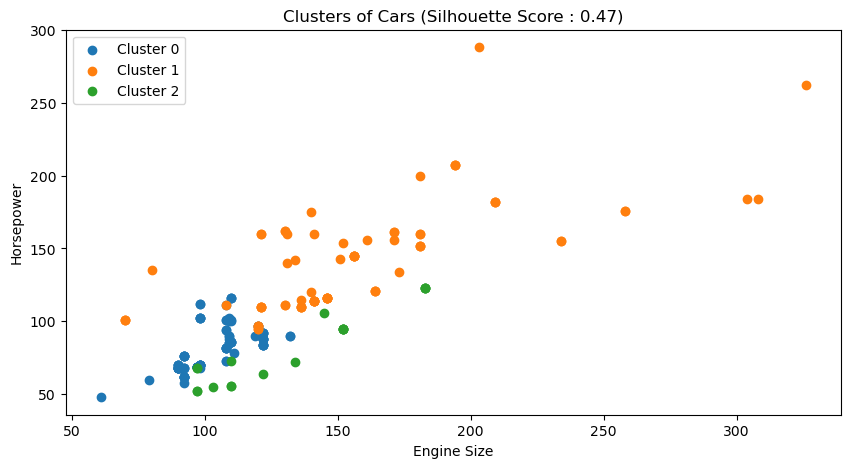

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Load the dataset
df = pd.read_csv('CarPrice_Assignment.csv')

# Display the first few rows of the dataset
print(df.head())
# print(df.info())
# print(df.describe())

# Check for missing values
# print(df.isnull().sum())

# Select features for clustering
# Let's consider 'fueltype', 'enginesize', 'horsepower', 'citympg', 'highwaympg' for clustering
# Encoding 'fueltype' to numeric
df['fueltype'] = df['fueltype'].map({'gas': 0, 'diesel': 1})

# Selecting the relevant features
features = ['fueltype', 'enginesize', 'horsepower', 'citympg', 'highwaympg']
X = df[features]

# Normalize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Assume the optimal number of clusters is 3
kmeans = KMeans(n_clusters=3, init='k-means++', max_iter=300, n_init=10, random_state=42)
clusters = kmeans.fit_predict(X_scaled)
silhouette_avg = silhouette_score(X_scaled, clusters)

# Add the cluster labels to the original dataframe
df['Cluster'] = clusters

# Plot the clusters
plt.figure(figsize=(10, 5))
for cluster in np.unique(clusters):
    plt.scatter(df[df['Cluster'] == cluster]['enginesize'],
                df[df['Cluster'] == cluster]['horsepower'],
                label=f'Cluster {cluster}')

plt.title(f'Clusters of Cars (Silhouette Score : {silhouette_avg:.2f})')
plt.xlabel('Engine Size')
plt.ylabel('Horsepower')
plt.legend()
plt.show()
